# Perfiles Hernquist autoconsistentes: resultados de results/Hernquist_test_1200

Los nueve archivos NPZ se grafican individualmente y en conjunto. Se muestran además la pendiente local, los errores relativos y comparaciones con perfiles analíticos de $\gamma=1$. Los radios están en pc y las densidades en $M_\odot/\mathrm{pc}^3$.

**Procedencia:** los NPZ existentes registran $M_{\rm halo}=6.06\times10^{11}M_\odot$ y $a=40$ kpc. Los modelos analíticos de comparación usan los valores corregidos $M_{\rm halo}=2.06\times10^{11}M_\odot$ y $a=40$ kpc. Por tanto, las curvas numéricas y analíticas no corresponden a una misma masa de halo.

Los ejes de los perfiles muestran $\log_{10}(r/R_S)$ y $\log_{10}[\rho^\prime/(M_\odot\,\mathrm{pc}^{-3})]$, donde $R_S$ es el radio de Schwarzschild.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

# El notebook vive en la raíz del repositorio; también funciona si el kernel
# se inicia desde una subcarpeta del proyecto.
ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / 'results' / 'Hernquist_test_1200').is_dir() and (p / 'src' / 'dm_spikes').is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('No se encontró la raíz del repositorio con results/Hernquist_test_1200.')
sys.path.insert(0, str(ROOT / 'src'))

from dm_spikes.density_models import hernquist, power_law
from dm_spikes.final_profile import schwarzschild_radius
from dm_spikes.power_law_profile import D, rho_D, cusp_profile, gamma_spike, spike_radius

results_dir = ROOT / 'results' / 'Hernquist_test_1200'
result_files = sorted(results_dir.glob('*.npz'))
if not result_files:
    raise FileNotFoundError(f'No hay archivos NPZ en {results_dir}')

records = []
for path in result_files:
    with np.load(path, allow_pickle=False) as data:
        radii = np.asarray(data['radii'], dtype=float).copy()
        density = np.asarray(data['rho_prime'], dtype=float).copy()
        config = json.loads(data['config_json'].item())
        is_final = 'iterations' in data.files
        iteration = int(data['iterations' if is_final else 'iteration'].item())
        converged = bool(data['converged'].item())
    if radii.ndim != 1 or radii.shape != density.shape:
        raise ValueError(f'Malla y densidad incompatibles: {path.name}')
    if not (np.all(np.isfinite(radii)) and np.all(np.isfinite(density))
            and np.all(radii > 0) and np.all(density > 0)):
        raise ValueError(f'Los ejes logarítmicos requieren datos finitos y positivos: {path.name}')
    label = f'Final ({iteration} iteraciones)' if is_final else f'Iteración {iteration:03d}'
    records.append(dict(path=path, radii=radii, density=density, config=config,
                        is_final=is_final, iteration=iteration,
                        converged=converged, label=label))
records.sort(key=lambda rec: (rec['is_final'], rec['iteration'], rec['path'].name))

reference = next(rec for rec in records if rec['is_final'])['config']
R_S = schwarzschild_radius(reference['M_bh'], G=reference['G'], clight=reference['clight'])

# Mismo limite visible que el grafico de densidades de perfiles_analiticos.ipynb:
# 4.0001 R_S hasta el mayor R_sp de gamma=0.01,...,1.99, con margen del 5 %.
reference_gammas = np.arange(0.01, 2.00, 0.01)
reference_rsp = spike_radius(reference['M_bh'], reference_gammas,
                             rho_D(reference_gammas), D)
reference_x_start = np.log10(4.0001)
reference_x_end = np.log10(np.max(reference_rsp) / R_S)
reference_x_left = reference_x_start - 0.05 * (reference_x_end - reference_x_start)

r_min = min(rec['radii'].min() for rec in records)
r_max = max(rec['radii'].max() for rec in records)
rho_min = min(rec['density'].min() for rec in records)
rho_max = max(rec['density'].max() for rec in records)

def format_axes(ax, title):
    ax.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
           ylim=(np.log10(rho_min / 2), np.log10(rho_max * 2)),
           title=title,
           xlabel=r'$\log_{10}(r/R_S)$',
           ylabel=r'$\log_{10}[\rho^\prime(r)/(M_\odot\,\mathrm{pc}^{-3})]$')
    ax.grid(True, alpha=0.25)

print(f'{len(records)} resultados cargados desde {results_dir}')
print(', '.join(rec['path'].name for rec in records))

9 resultados cargados desde C:\Users\luisa\Documents\Repo GitHub\DM-spikes\results\Hernquist_test_1200
hernquist_380mpc_20261007_223006_iter_001.npz, hernquist_380mpc_20261007_223006_iter_002.npz, hernquist_380mpc_20261007_223006_iter_003.npz, hernquist_380mpc_20261007_223006_iter_004.npz, hernquist_380mpc_20261007_223006_iter_005.npz, hernquist_380mpc_20261007_223006_iter_006.npz, hernquist_380mpc_20261007_223006_iter_007.npz, hernquist_380mpc_20261007_223006_iter_008.npz, hernquist_380mpc_20261007_223006_final.npz


## Cada resultado por separado

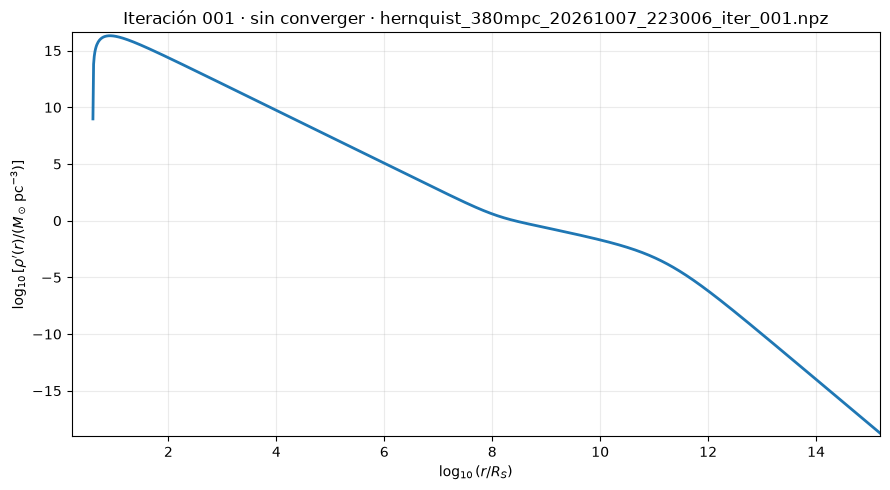

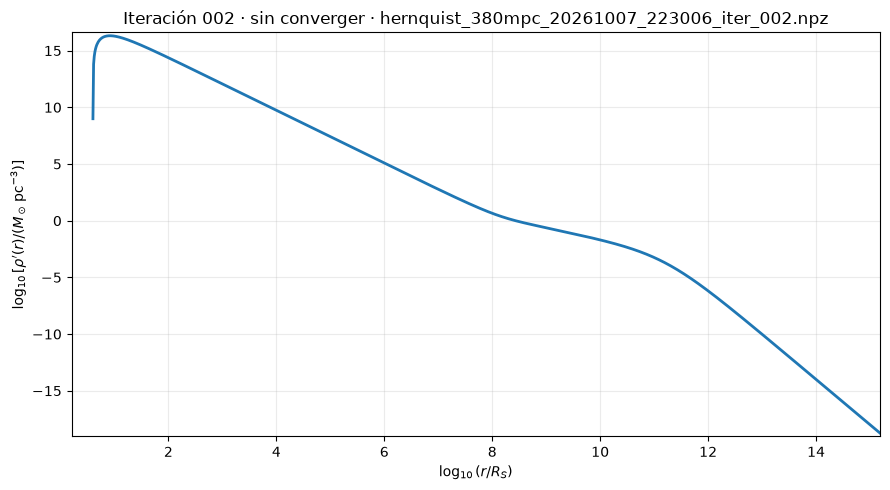

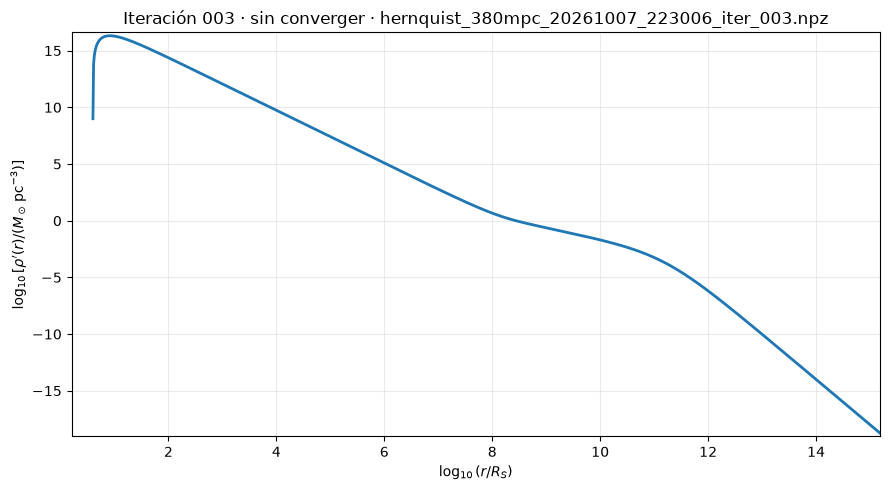

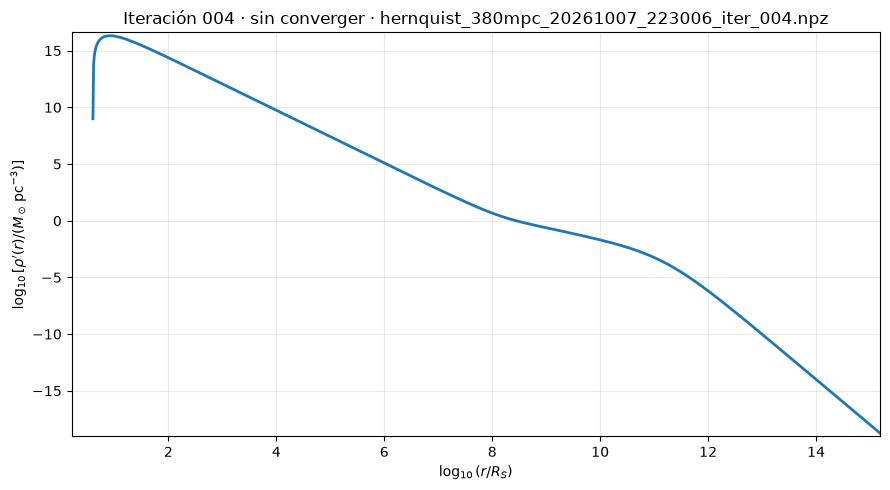

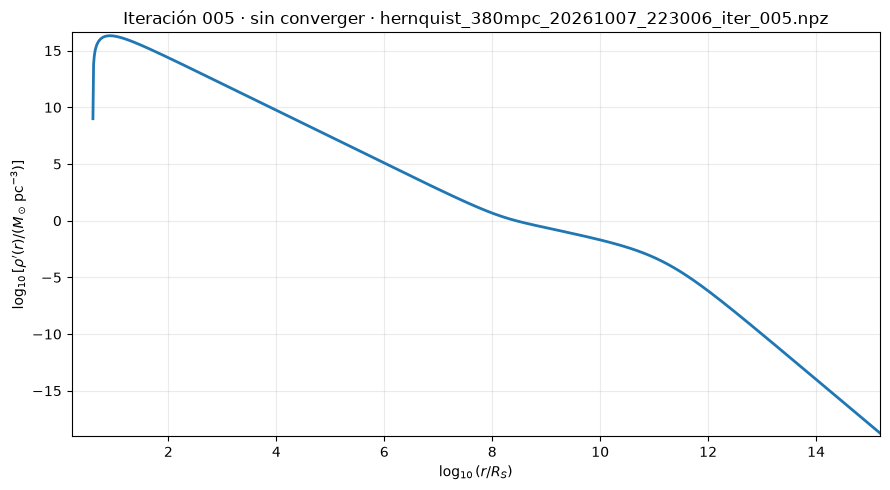

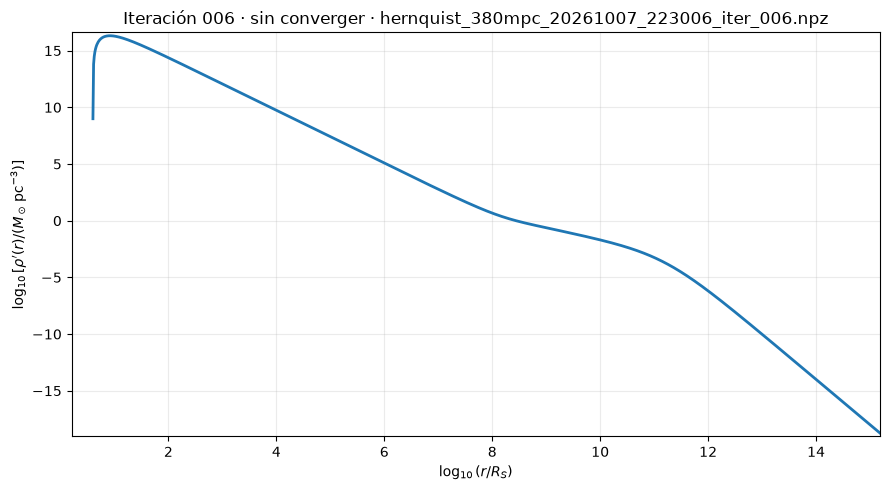

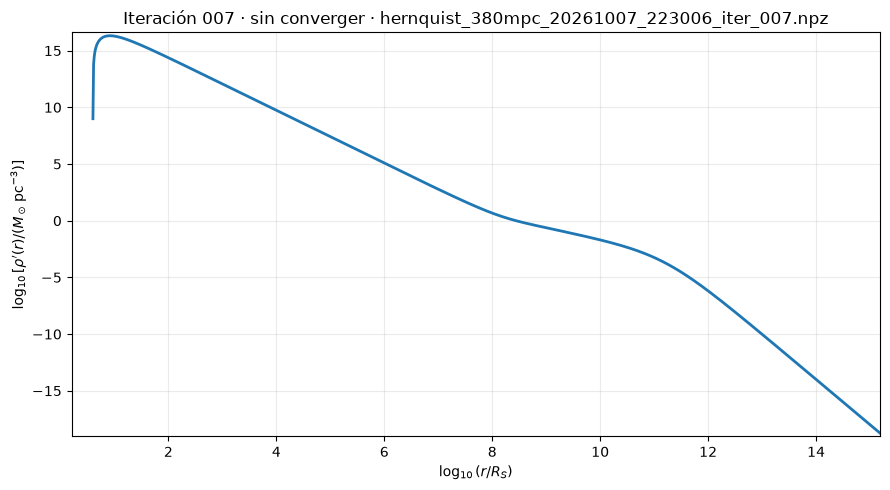

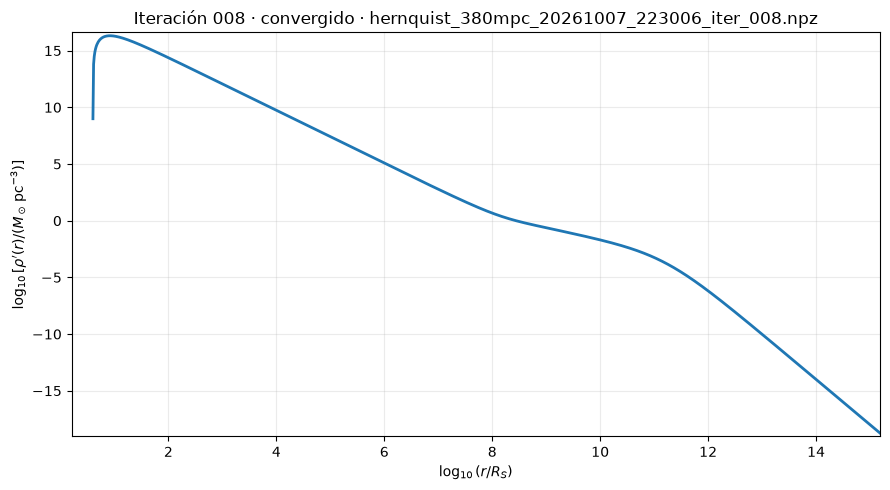

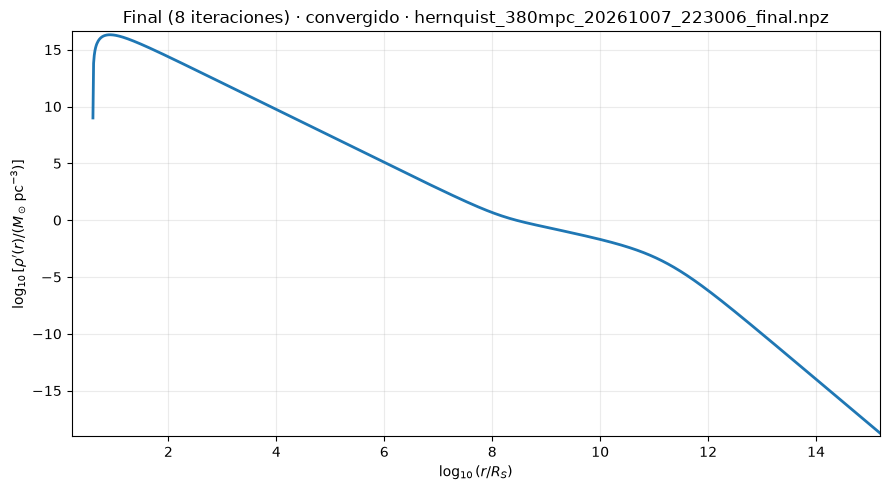

In [2]:
for rec in records:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']), linewidth=2)
    status = 'convergido' if rec['converged'] else 'sin converger'
    format_axes(ax, f"{rec['label']} · {status} · {rec['path'].name}")
    fig.tight_layout()
    plt.show()

## Todos los resultados superpuestos

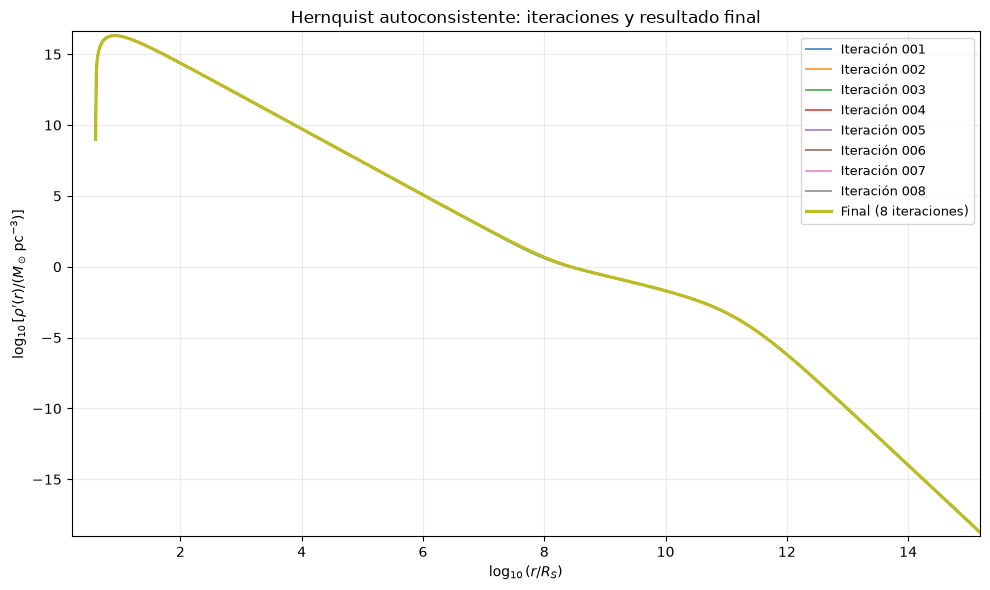

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for rec in records:
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']), label=rec['label'],
            linewidth=2.3 if rec['is_final'] else 1.4,
            alpha=1 if rec['is_final'] else 0.75)
format_axes(ax, 'Hernquist autoconsistente: iteraciones y resultado final')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()

## Comparación con el perfil analítico final para $\gamma=1$

Para la masa corregida $M_{\rm halo}=2.06\times10^{11}M_\odot$ y $a=40$ kpc se toman $r_0=a$ y $\rho_0=M_{\rm halo}/(2\pi a^3)$. Así, la ley de potencia inicial de $\gamma=1$ comparte el coeficiente interior de un Hernquist con esos parámetros. Su perfil final se dibuja entre $4.0001R_S$ y su propio $R_{\rm sp}$. Los NPZ numéricos fueron calculados con $6.06\times10^{11}M_\odot$, por lo que esta superposición muestra dos modelos con masas distintas.

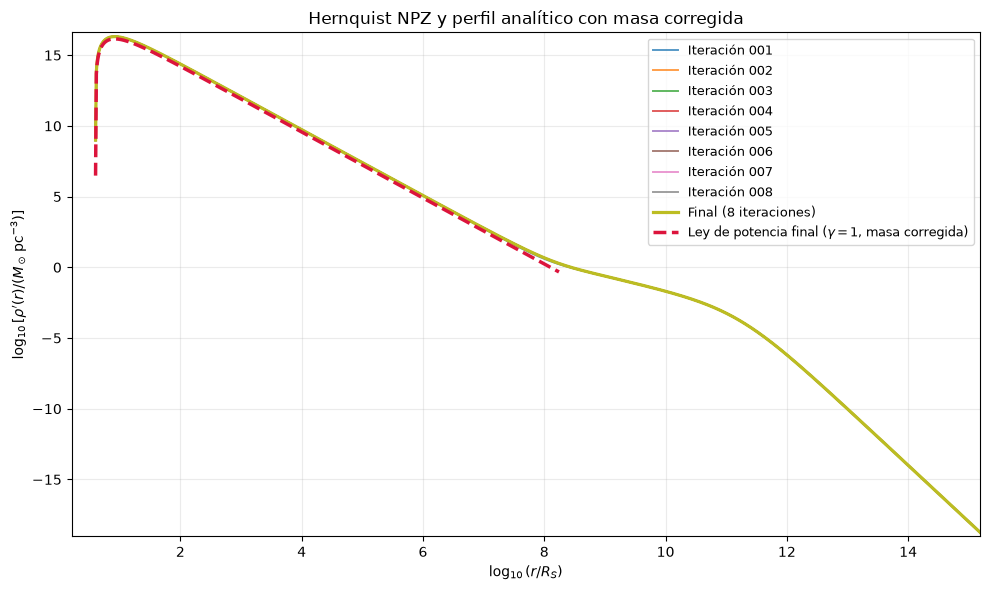

R_S = 2.48841e-07 pc; R_sp = 43.4297 pc; M_halo del NPZ = 6.06e+11 Msun; M_halo analítico = 2.06e+11 Msun; a = 40000 pc; rho0 interior = 0.00051228 Msun/pc³


In [4]:
for rec in records:
    config = rec['config']
    if (config['M_bh'] != reference['M_bh']
            or config['clight'] != reference['clight']
            or config['G'] != reference['G']
            or config['density'] != reference['density']):
        raise ValueError(f"Normalización distinta en {rec['path'].name}")

gamma = 1.0
M_bh = reference['M_bh']
M_halo_NPZ = reference['density']['parameters']['total_mass']
a_NPZ = reference['density']['parameters']['scale_radius']
M_halo = 2.06e11  # Msun: valor corregido para los modelos analiticos
a = 40_000.0     # pc = 40 kpc
if a_NPZ != a:
    raise ValueError(f"El radio de escala del NPZ ({a_NPZ:g} pc) no es 40 kpc")
rho0_inner = M_halo / (2.0 * np.pi * a**3)
r0_inner = a
R_sp = spike_radius(M_bh, gamma, rho0_inner, r0_inner)
r_power_law = np.geomspace(4.0001 * R_S, R_sp, 600)
rho_power_law = cusp_profile(r_power_law, M_bh, gamma, R_S,
                             r0=r0_inner, rho0=rho0_inner)

fig, ax = plt.subplots(figsize=(10, 6))
for rec in records:
    ax.plot(np.log10(rec['radii'] / R_S), np.log10(rec['density']),
            label=rec['label'], linewidth=2.3 if rec['is_final'] else 1.4,
            alpha=1 if rec['is_final'] else 0.75)
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law),
        color='crimson', linestyle='--', linewidth=2.5,
        label=r'Ley de potencia final ($\gamma=1$, masa corregida)',
        zorder=10)
format_axes(ax, 'Hernquist NPZ y perfil analítico con masa corregida')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()
print(f'R_S = {R_S:.6g} pc; R_sp = {R_sp:.6g} pc; '
      f'M_halo del NPZ = {M_halo_NPZ:g} Msun; M_halo analítico = {M_halo:g} Msun; a = {a:g} pc; '
      f'rho0 interior = {rho0_inner:.6g} Msun/pc³')

## Perfil convergido y pendiente logarítmica local

El panel superior representa la densidad en coordenadas logarítmicas. El inferior muestra $\gamma_{\mathrm{eff}}(r)=-d\ln\rho^\prime/d\ln r$, calculada por diferencias centradas en $\ln r$. Se omiten veinte puntos en cada extremo del panel de pendientes.

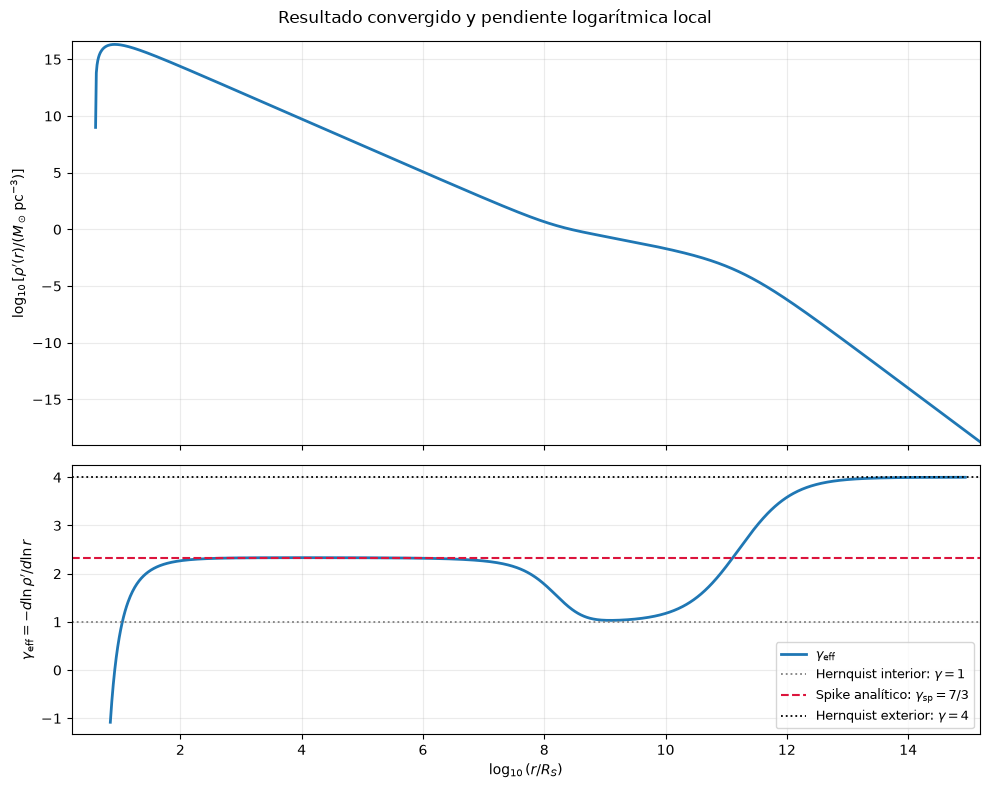

In [5]:
converged_record = next(rec for rec in records if rec['is_final'] and rec['converged'])
r_converged = converged_record['radii']
rho_converged = converged_record['density']
x_converged = np.log10(r_converged / R_S)
y_converged = np.log10(rho_converged)
gamma_eff = -np.gradient(np.log(rho_converged), np.log(r_converged))

trim = 20
fig, (ax_profile, ax_slope) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 2]}
)
ax_profile.plot(x_converged, y_converged, color='tab:blue', linewidth=2)
ax_profile.set_ylabel(r'$\log_{10}[\rho^\prime(r)/(M_\odot\,\mathrm{pc}^{-3})]$')
ax_profile.set_ylim(np.log10(rho_min / 2), np.log10(rho_max * 2))
ax_profile.grid(True, alpha=0.25)

ax_slope.plot(x_converged[trim:-trim], gamma_eff[trim:-trim],
              color='tab:blue', linewidth=2, label=r'$\gamma_{\mathrm{eff}}$')
ax_slope.axhline(1.0, color='gray', linestyle=':', linewidth=1.3,
                 label=r'Hernquist interior: $\gamma=1$')
ax_slope.axhline(gamma_spike(1.0), color='crimson', linestyle='--',
                 linewidth=1.5, label=r'Spike analítico: $\gamma_{\rm sp}=7/3$')
ax_slope.axhline(4.0, color='black', linestyle=':', linewidth=1.3,
                 label=r'Hernquist exterior: $\gamma=4$')
ax_slope.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
             xlabel=r'$\log_{10}(r/R_S)$',
             ylabel=r'$\gamma_{\mathrm{eff}}=-d\ln\rho^\prime/d\ln r$')
ax_slope.grid(True, alpha=0.25)
ax_slope.legend(loc='best', fontsize=9)
fig.suptitle('Resultado convergido y pendiente logarítmica local')
fig.tight_layout()
plt.show()

## Error relativo frente al resultado convergido

Para cada archivo de results/Hernquist_test_1200 se representa $|\rho_i^\prime(r)-\rho_{\mathrm{conv}}^\prime(r)|/\rho_{\mathrm{conv}}^\prime(r)$. La escala vertical symlog permite ver simultáneamente errores de varios órdenes de magnitud y el cero de la referencia convergida.

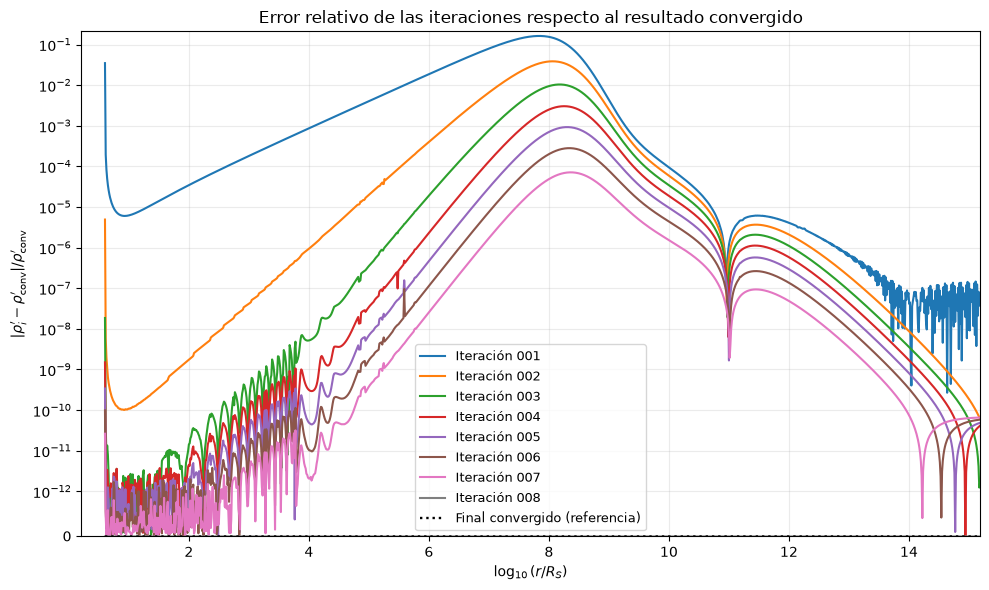

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
max_error = 0.0
for rec in records:
    if not np.array_equal(rec['radii'], r_converged):
        raise ValueError(f"Malla radial distinta en {rec['path'].name}")
    relative_error = np.abs(rec['density'] - rho_converged) / rho_converged
    max_error = max(max_error, float(np.max(relative_error)))
    if rec['is_final']:
        ax.plot(np.log10(rec['radii'] / R_S), relative_error,
                color='black', linestyle=':', linewidth=1.7,
                label='Final convergido (referencia)')
    else:
        ax.plot(np.log10(rec['radii'] / R_S), relative_error,
                linewidth=1.5, label=rec['label'])

ax.set(xlim=(reference_x_left, np.log10(r_max / R_S)),
       ylim=(0, max_error * 1.3),
       xlabel=r'$\log_{10}(r/R_S)$',
       ylabel=r'$|\rho_i^\prime-\rho_{\rm conv}^\prime|/\rho_{\rm conv}^\prime$',
       title='Error relativo de las iteraciones respecto al resultado convergido')
ax.set_yscale('symlog', linthresh=1e-12)
ax.grid(True, alpha=0.25)
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()

## Resultado convergido y perfiles iniciales y finales

El resultado convergido proviene del NPZ con $M_{\rm halo}=6.06\times10^{11}M_\odot$. El Hernquist inicial y las leyes de potencia inicial y final se calculan con la masa corregida $2.06\times10^{11}M_\odot$ y $a=40$ kpc. Las leyes de potencia usan $\gamma=1$, $\rho_0=M_{\rm halo}/(2\pi a^3)$ y $r_0=a$, y llegan a $R_{\rm sp}$. La inicial aparece con cruces verdes sin línea.

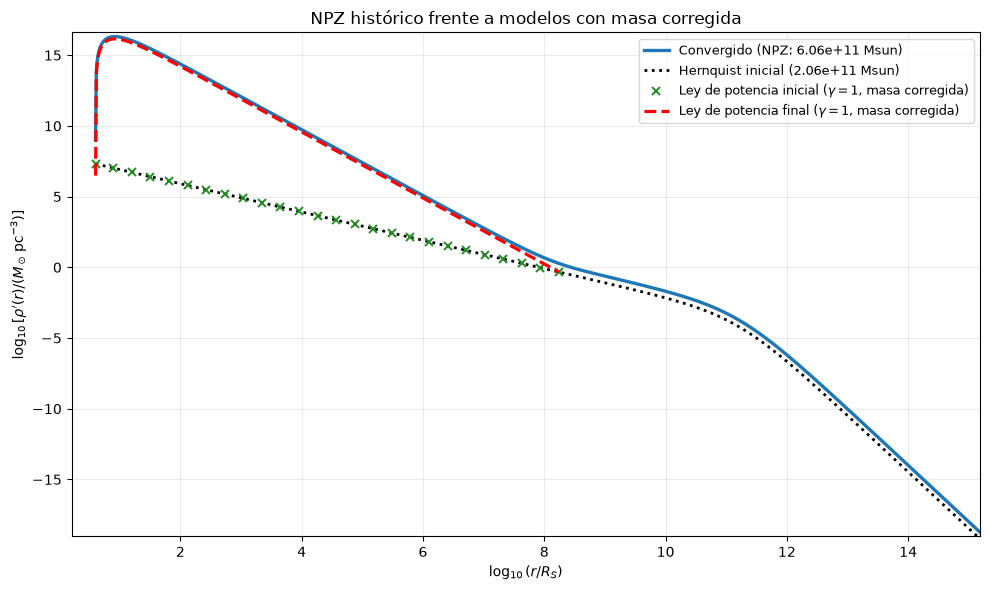

In [7]:
rho_hernquist_initial = hernquist(
    total_mass=M_halo, scale_radius=a
)(r_converged)
rho_power_law_initial = power_law(
    rho0=rho0_inner, r0=r0_inner, gamma=gamma
)(r_power_law)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_converged, y_converged, color='tab:blue', linewidth=2.4,
        label=f'Convergido (NPZ: {M_halo_NPZ:.2e} Msun)')
ax.plot(x_converged, np.log10(rho_hernquist_initial), color='black',
        linestyle=':', linewidth=2.0,
        label=f'Hernquist inicial ({M_halo:.2e} Msun)')
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law_initial),
        color='forestgreen', linestyle='None', marker='x', markersize=6,
        markeredgewidth=1.4,
        markevery=np.linspace(0, len(r_power_law) - 1, 26, dtype=int),
        label=r'Ley de potencia inicial ($\gamma=1$, masa corregida)')
ax.plot(np.log10(r_power_law / R_S), np.log10(rho_power_law),
        color='red', linestyle='--', linewidth=2.3,
        label=r'Ley de potencia final ($\gamma=1$, masa corregida)')

format_axes(ax, 'NPZ histórico frente a modelos con masa corregida')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
plt.show()